<a href="https://colab.research.google.com/github/EtzionR/LM4GeoAI/blob/main/Tutorials/Tutorial_Embedding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial: Textual Embedding

### created by Etzion Harari | Geo-AI Course

[**https://github.com/EtzionR/LM4GeoAI**](https://github.com/EtzionR/LM4GeoAI)

## Imports

In [50]:
from transformers import pipeline, AutoTokenizer
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np

## Define embedding model

In [2]:
MODEL = "intfloat/multilingual-e5-large"
MODEL

'intfloat/multilingual-e5-large'

## Init embedding object

In [3]:
embedder = pipeline("feature-extraction", model=MODEL)
embedder

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Device set to use cpu


## Define embedding function

In [14]:
get_text_embedding  = lambda text: np.array(embedder(text))

embedding_example = get_text_embedding('input text example')
embedding_example

array([[[ 0.83128393,  0.16302121, -0.50380039, ..., -0.03575357,
         -0.91171736, -0.13225469],
        [ 0.71026063,  0.09593981, -0.71713895, ..., -0.23332611,
         -0.48675567, -0.20810498],
        [ 0.66047913,  0.140926  , -0.56703663, ..., -0.22211613,
         -0.73921603, -0.28269243],
        [ 0.83910984,  0.13433495, -0.46818447, ..., -0.15230688,
         -0.65619582, -0.57051092],
        [ 0.83135504,  0.16320597, -0.50365496, ..., -0.03601924,
         -0.91154402, -0.13219677]]])

## Display vector values using matplotlib

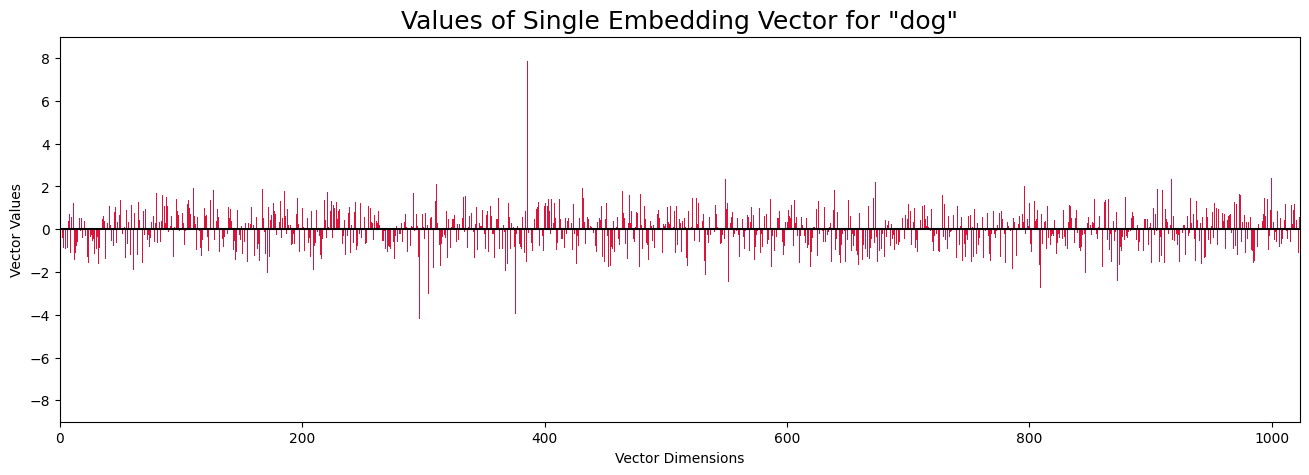

In [45]:
word_example = 'dog'

vector = get_text_embedding(word_example)[0][1]
y_max = (np.abs(vector).max()//1)+2

plt.figure(figsize=(16,5))
plt.title(f'Values of Single Embedding Vector for "{word_example}"', fontsize=18)
plt.bar(np.arange(len(vector)), vector, color='crimson')
plt.plot([0, len(vector)-1],[0,0], color='k')
plt.xlabel('Vector Dimensions')
plt.ylabel('Vector Values')
plt.xlim(-.5, len(vector)-.5)
plt.ylim(-y_max, y_max)
plt.show()


## Simple embedding experiment

In [5]:
king  = 'king'
queen = 'queen'
kong  = 'kong'

king_embedding = get_text_embedding(king)[0][-2]
queen_embedding = get_text_embedding(queen)[0][-2]
kong_embedding = get_text_embedding(kong)[0][-2]

king_to_queen = ((king_embedding - queen_embedding)**2).mean().round(3)
king_to_kong  = ((king_embedding - kong_embedding)**2).mean().round(3)
queen_to_kong = ((queen_embedding - kong_embedding)**2).mean().round(3)

print(f'Distance between king and queen: {king_to_queen}')
print(f'Distance between king and kong:  {king_to_kong}')
print(f'Distance between queen and kong: {queen_to_kong}')

Distance between king and queen: 0.235
Distance between king and kong:  0.294
Distance between queen and kong: 0.356


## Contextual embedding experiment

In [6]:
first_example_text = 'Dog, cat and mouse'
second_example_text = 'Computer, keyboard and mouse'

print(f'First text length: {len(first_example_text)}\nSecond text length: {len(second_example_text)}')

First text length: 18
Second text length: 28


## Tokenization process example

In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL)

tokenized_first_text = tokenizer.convert_ids_to_tokens(tokenizer(first_example_text)['input_ids'])
tokenized_second_text = tokenizer.convert_ids_to_tokens(tokenizer(second_example_text)['input_ids'])

print(f'First text after tokenization:\t{tokenized_first_text} (length = {len(tokenized_first_text)})')
print(f'Second text after tokenization:\t{tokenized_second_text} (length = {len(tokenized_second_text)})')

First text after tokenization:	['<s>', '▁Dog', ',', '▁cat', '▁and', '▁mouse', '</s>'] (length = 7)
Second text after tokenization:	['<s>', '▁Computer', ',', '▁keyboard', '▁and', '▁mouse', '</s>'] (length = 7)


## First input embedding output

In [8]:
first_output = get_text_embedding(first_example_text)

first_output.shape

(1, 7, 1024)

## Second input embedding output

In [9]:
second_output = get_text_embedding(second_example_text)

second_output.shape

(1, 7, 1024)

## The embedding for "mouse" (for the first text)

In [10]:
mouse1 = first_output[0][-2]
mouse1

array([ 0.40990537,  0.22689098, -0.85698527, ..., -0.42554951,
       -1.81469822, -0.54044932])

## The embedding for "mouse" (for the second text)

In [11]:
mouse2 = second_output[0][-2]
mouse2

array([ 0.96612078,  0.66941226, -1.14001143, ..., -0.12522529,
       -0.43087456, -0.58664805])

## Distance $\Delta$ between the embedding of "mouse" in the first text and the embedding of "mouse" in the second text

$X = Mouse_1$

$Y = Mouse_2$

$\Delta = \frac{1}{N}\sum_{i=1}^{N}(X_i-Y_i)^2$

Where $N$ equal to the length of vectors $X$ and $Y$.

In [12]:
float(((mouse1 - mouse2)**2).mean().round(5))


0.15984

Create by Etzion Harari | Geo-AI Course | [https://github.com/EtzionR/LM4GeoAI](https://github.com/EtzionR/LM4GeoAI)